<a href="https://colab.research.google.com/github/ham-codes7/Exploratory-Data-Analysis-/blob/main/Exp9_15_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Sports & Outdoors']
countries = ['United States', 'India', 'United Kingdom', 'Germany', 'Brazil',
             'Japan', 'Canada', 'Australia', 'France', 'South Africa',
             'Mexico', 'China', 'Italy', 'Nigeria', 'South Korea']

# Each category has a distinct statistical "profile" so clustering/pairplot/
# dendrogram visuals show real separation instead of random noise.
category_profiles = {
    'Electronics':       {'price': (450, 150), 'rating': (4.2, 0.4), 'margin': (18, 4), 'marketing': (5000, 1200), 'units': (200, 60)},
    'Clothing':          {'price': (40, 15),  'rating': (3.8, 0.5), 'margin': (35, 6), 'marketing': (2000, 600),  'units': (500, 150)},
    'Home & Kitchen':    {'price': (90, 30),  'rating': (4.0, 0.4), 'margin': (28, 5), 'marketing': (2800, 700),  'units': (300, 90)},
    'Books':             {'price': (15, 5),   'rating': (4.4, 0.3), 'margin': (40, 5), 'marketing': (800, 300),  'units': (700, 200)},
    'Sports & Outdoors': {'price': (65, 20),  'rating': (4.1, 0.4), 'margin': (30, 5), 'marketing': (1800, 500), 'units': (350, 100)},
}

review_words = {
    'Electronics': ['fast','sleek','powerful','battery','screen','innovative','reliable','pricey','lag','sturdy'],
    'Clothing': ['comfortable','stylish','soft','trendy','fit','fabric','affordable','fashionable','cozy','breathable'],
    'Home & Kitchen': ['durable','handy','efficient','compact','useful','sturdy','practical','easy','clean','versatile'],
    'Books': ['engaging','insightful','captivating','wellwritten','inspiring','thoughtful','gripping','educational','moving','clever'],
    'Sports & Outdoors': ['durable','lightweight','rugged','comfortable','reliable','tough','breathable','sturdy','supportive','active']
}

rows_per_category = 60
records = []
pid = 1000

for cat in categories:
    p = category_profiles[cat]
    for _ in range(rows_per_category):
        price = max(5, np.random.normal(*p['price']))
        rating = np.clip(np.random.normal(*p['rating']), 1, 5)
        margin = np.clip(np.random.normal(*p['margin']), 2, 60)
        marketing = max(100, np.random.normal(*p['marketing']))
        units = max(5, np.random.normal(*p['units']))
        country = np.random.choice(countries)
        review = ' '.join(np.random.choice(review_words[cat], size=6, replace=True))
        customer_age = int(np.clip(np.random.normal(34, 10), 16, 70))
        records.append({
            'product_id': pid, 'category': cat, 'country': country,
            'price': round(price, 2), 'units_sold': int(units),
            'rating': round(rating, 2), 'profit_margin_pct': round(margin, 2),
            'marketing_spend': round(marketing, 2), 'customer_age': customer_age,
            'review_text': review
        })
        pid += 1

df = pd.DataFrame(records)
df['revenue'] = (df['price'] * df['units_sold']).round(2)
df.head()

,product_id,category,country,price,units_sold,rating,profit_margin_pct,marketing_spend,customer_age,review_text,revenue
0,1000,Electronics,Mexico,524.51,185,4.14,20.59,6827.64,31,pricey screen battery pricey pricey powerful,97034.35
1,1001,Electronics,China,379.58,214,4.42,16.15,4441.12,16,lag fast sturdy powerful reliable battery,81230.12
2,1002,Electronics,Germany,368.34,163,4.24,13.40,5450.84,31,reliable pricey powerful fast battery sleek,60039.42
3,1003,Electronics,South Korea,260.23,213,4.64,29.11,6432.37,42,pricey reliable lag pricey screen sleek,55428.99
4,1004,Electronics,Italy,801.11,142,4.63,18.39,5502.92,23,fast lag reliable lag pricey fast,113757.62


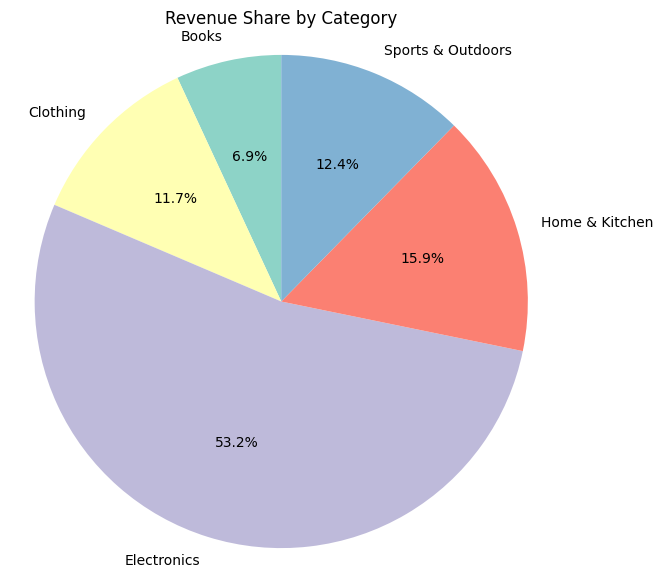

In [2]:
import matplotlib.pyplot as plt

def plot_pie(data, labels, title="Pie Chart"):
    plt.figure(figsize=(7,7))
    plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
    plt.title(title)
    plt.axis('equal')
    plt.show()

category_revenue = df.groupby('category')['revenue'].sum()
plot_pie(category_revenue.values, category_revenue.index, title="Revenue Share by Category")

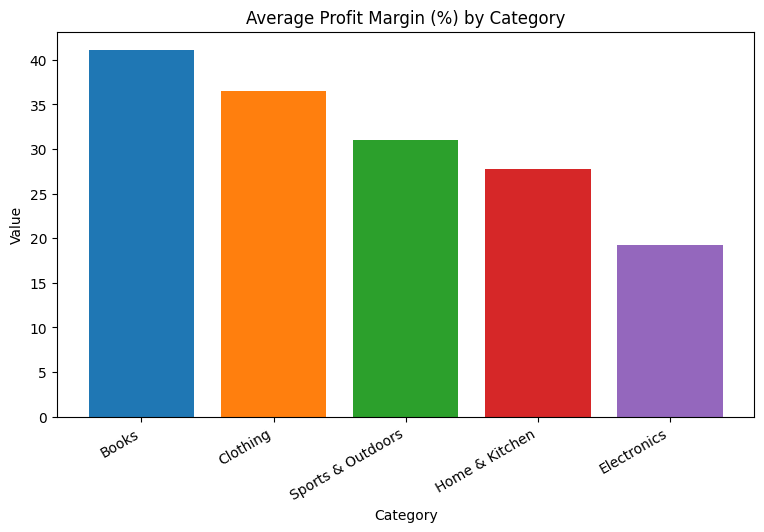

In [3]:
def plot_bar(categories, values, title="Bar Chart"):
    plt.figure(figsize=(9,5))
    plt.bar(categories, values, color=plt.cm.tab10.colors[:len(categories)])
    plt.title(title)
    plt.xlabel("Category")
    plt.ylabel("Value")
    plt.xticks(rotation=30, ha='right')
    plt.show()

avg_margin = df.groupby('category')['profit_margin_pct'].mean().sort_values(ascending=False)
plot_bar(avg_margin.index, avg_margin.values, title="Average Profit Margin (%) by Category")

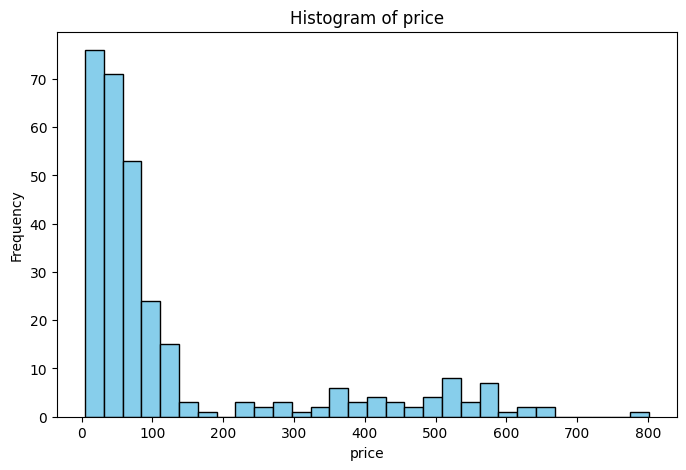

In [4]:
def plot_histogram(df, column):
    plt.figure(figsize=(8,5))
    plt.hist(df[column], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

plot_histogram(df, 'price')

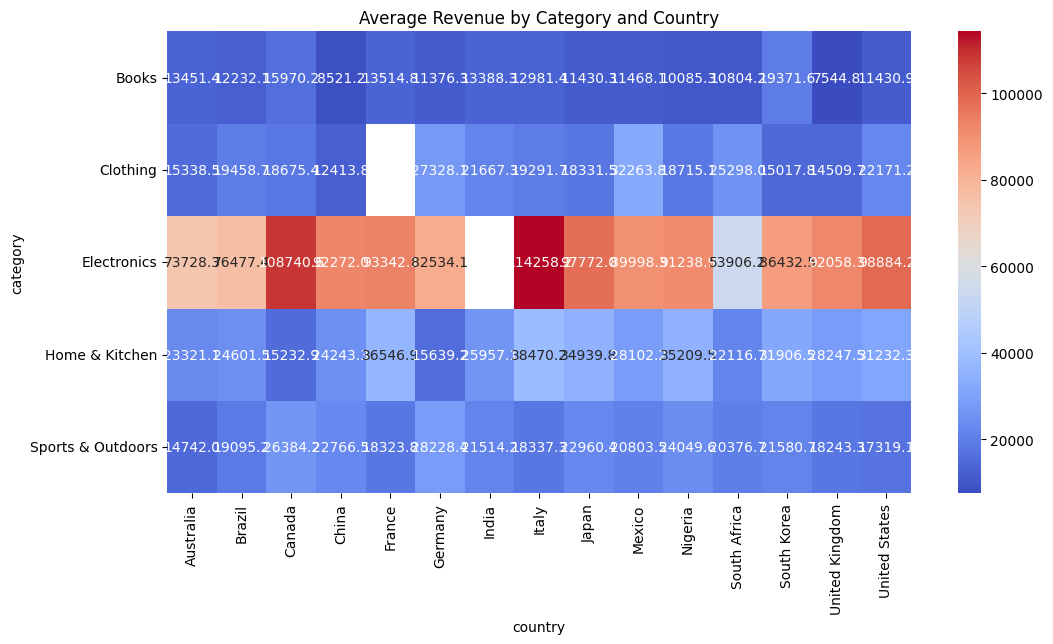

In [5]:
import seaborn as sns

def heatmap(data, annot=True, cmap='coolwarm'):
    plt.figure(figsize=(12,6))
    sns.heatmap(data, annot=annot, cmap=cmap, fmt=".1f")
    plt.title("Average Revenue by Category and Country")
    plt.show()

pivot = df.pivot_table(index='category', columns='country', values='revenue', aggfunc='mean')
heatmap(pivot, annot=True, cmap='coolwarm')

In [6]:
import plotly.express as px

country_revenue = df.groupby('country', as_index=False)['revenue'].sum()

fig = px.choropleth(country_revenue, locations='country', locationmode='country names',
                     color='revenue', color_continuous_scale='Viridis',
                     title='Total Revenue by Country')
fig.show()

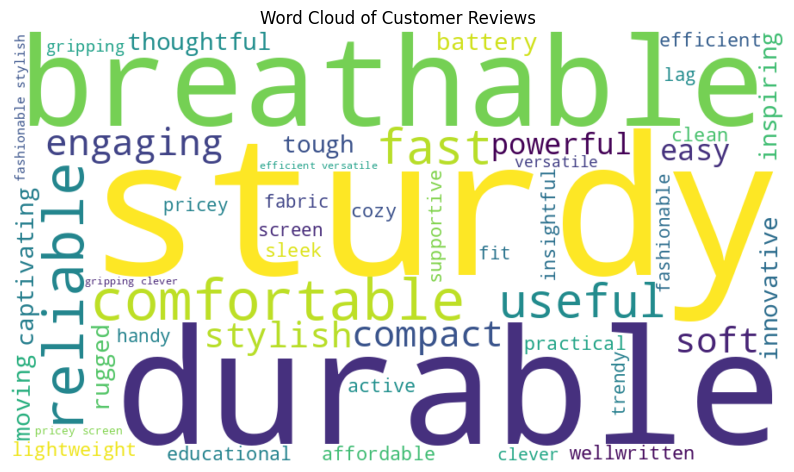

In [7]:
!pip install wordcloud -q
from wordcloud import WordCloud

text = ' '.join(df['review_text'])
wc = WordCloud(width=900, height=500, background_color='white', colormap='viridis').generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Customer Reviews")
plt.show()

/tmp/ipykernel_2080/3626083494.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



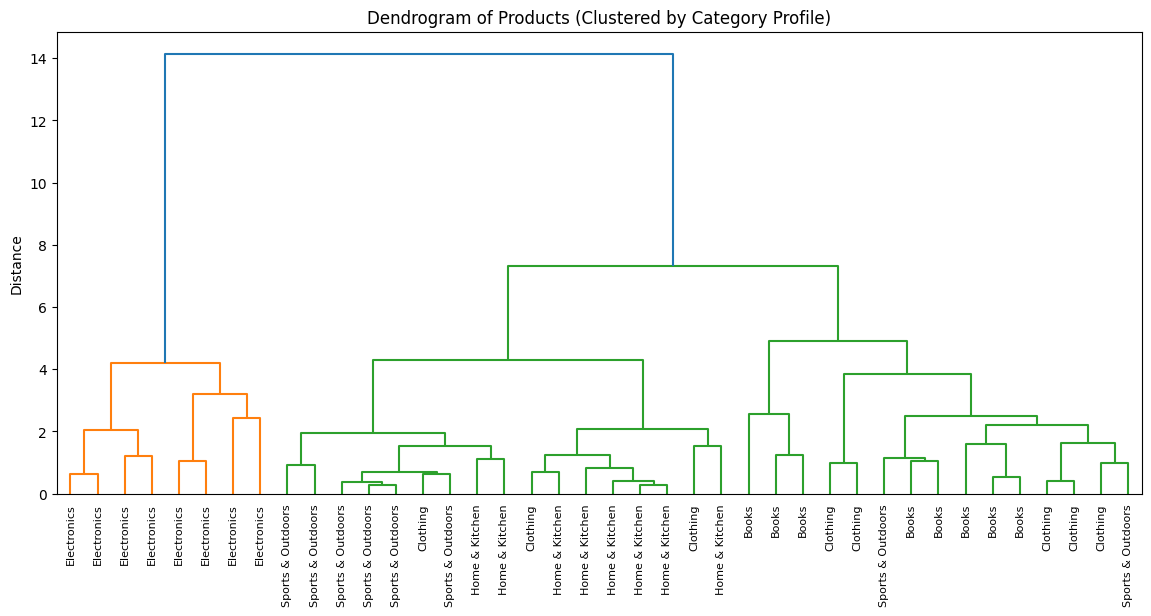

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Sample 8 products per category so the leaf labels stay readable
sample_df = df.groupby('category', group_keys=False).apply(lambda x: x.sample(8, random_state=1)).reset_index(drop=True)
features = ['price', 'rating', 'profit_margin_pct', 'marketing_spend', 'units_sold']
X = StandardScaler().fit_transform(sample_df[features])

Z = linkage(X, method='ward')

plt.figure(figsize=(14,6))
dendrogram(Z, labels=sample_df['category'].values, leaf_rotation=90)
plt.title("Dendrogram of Products (Clustered by Category Profile)")
plt.ylabel("Distance")
plt.show()

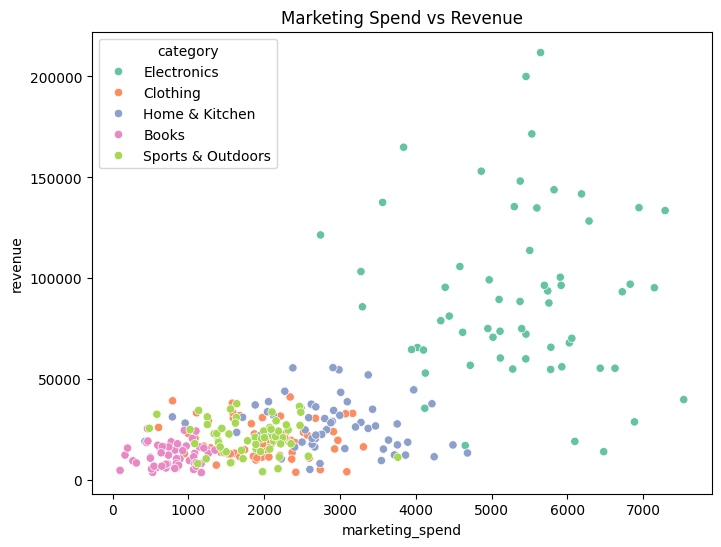

In [9]:
def scatter(x, y, hue=None, title="Scatter Plot"):
    plt.figure(figsize=(8,6))
    if hue is not None:
        sns.scatterplot(x=x, y=y, hue=hue, palette='Set2')
    else:
        plt.scatter(x, y, alpha=0.6)
    plt.title(title)
    plt.show()

scatter(df['marketing_spend'], df['revenue'], hue=df['category'], title="Marketing Spend vs Revenue")

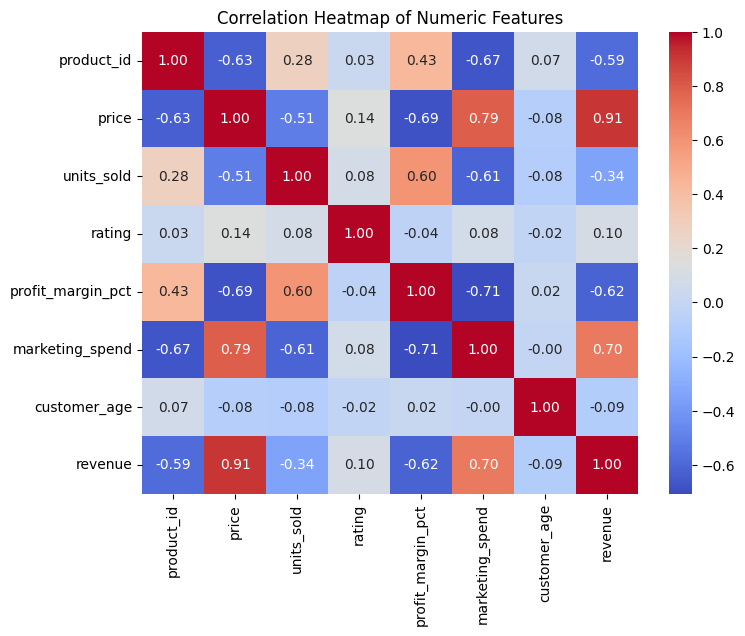

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

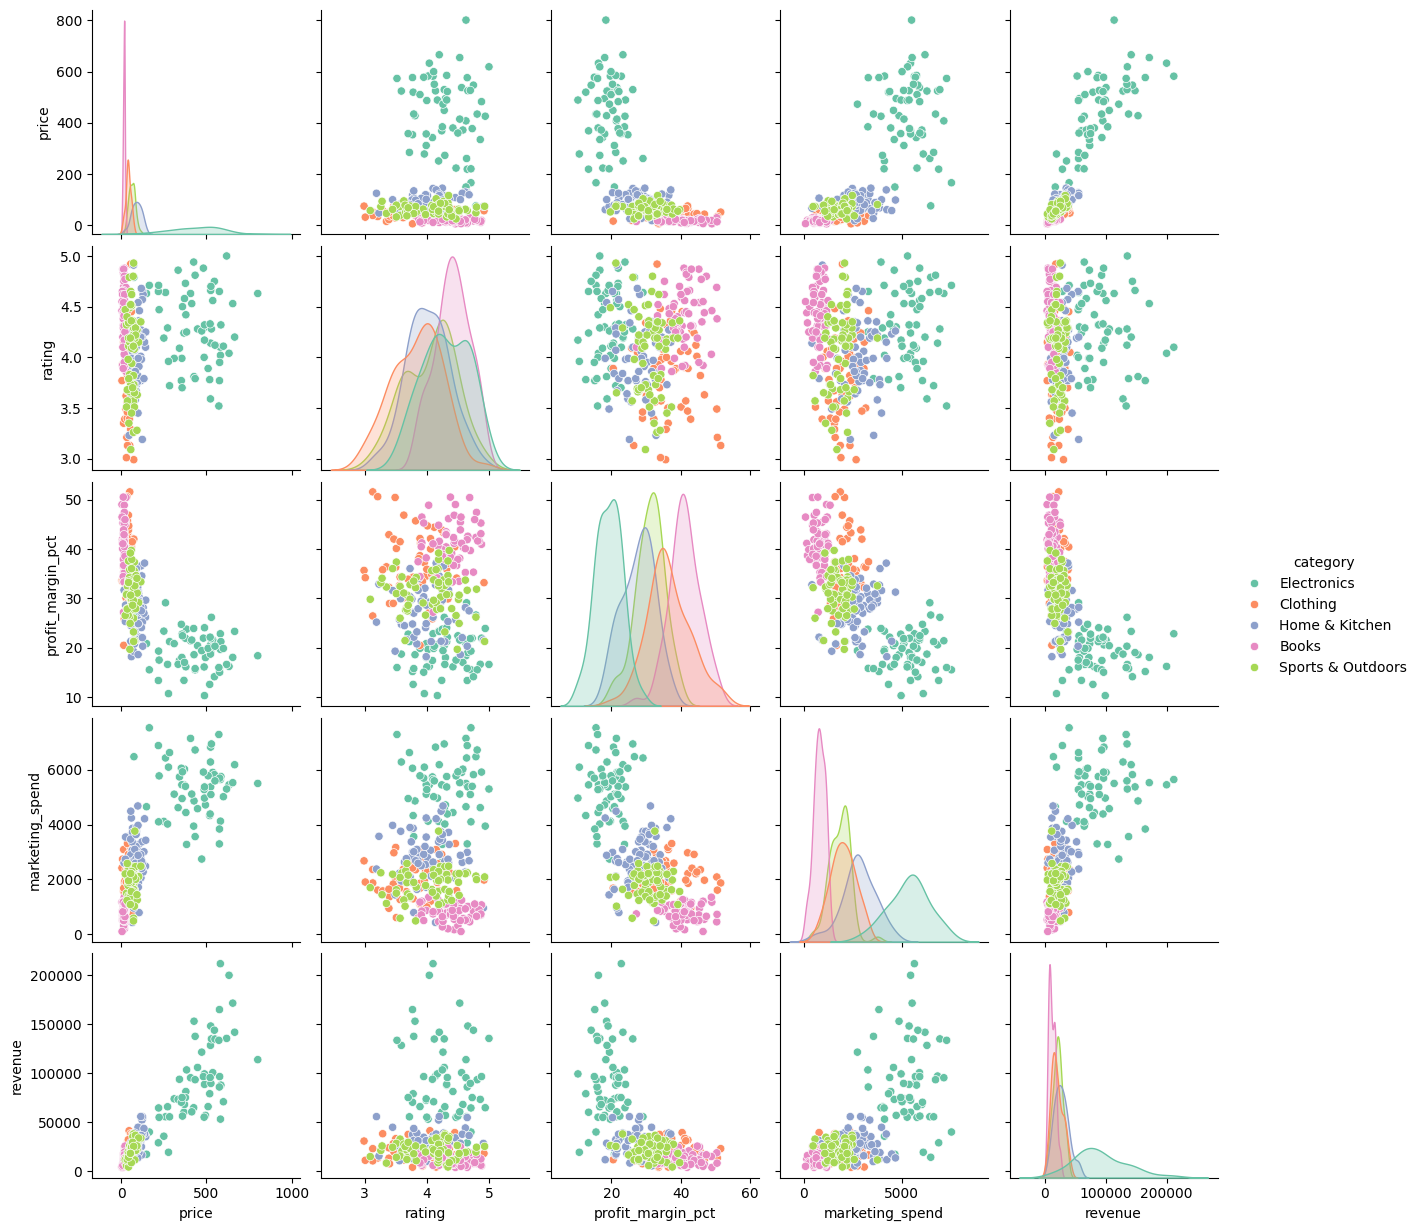

In [11]:
sns.pairplot(df[['price','rating','profit_margin_pct','marketing_spend','revenue','category']],
             hue='category', palette='Set2', diag_kind='kde')
plt.show()

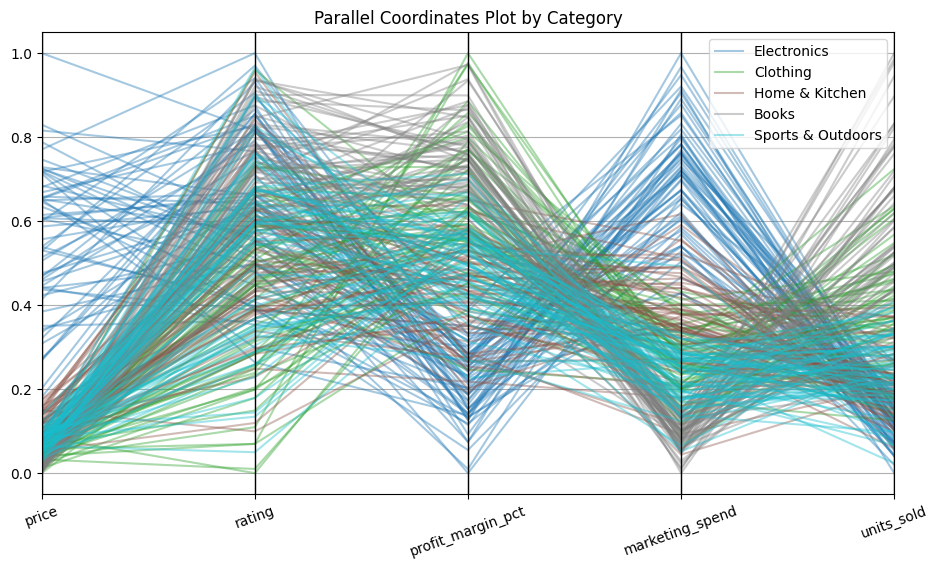

In [12]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

pc_df = df[['price','rating','profit_margin_pct','marketing_spend','units_sold','category']].copy()
num_cols = ['price','rating','profit_margin_pct','marketing_spend','units_sold']
pc_df[num_cols] = MinMaxScaler().fit_transform(pc_df[num_cols])

plt.figure(figsize=(11,6))
parallel_coordinates(pc_df, 'category', colormap='tab10', alpha=0.4)
plt.title("Parallel Coordinates Plot by Category")
plt.xticks(rotation=20)
plt.show()

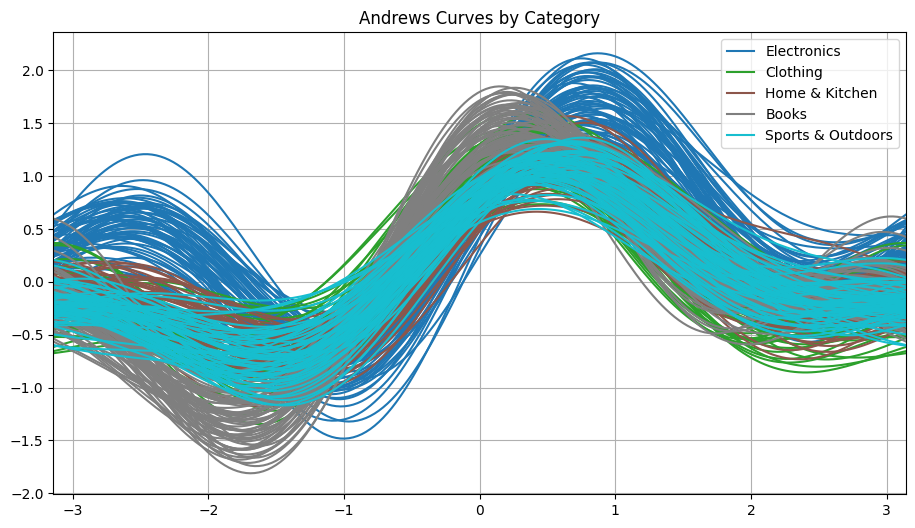

In [13]:
from pandas.plotting import andrews_curves

plt.figure(figsize=(11,6))
andrews_curves(pc_df, 'category', colormap='tab10')
plt.title("Andrews Curves by Category")
plt.show()